# ADS1001 Project Report Notebook

## Title
**Humidity and Dew Point in Malaysia: Which Variable Better Describes Oppressive Weather?**

## Research Question
**To what extent are humidity and dew point associated, and which variable is more useful for describing oppressive weather conditions in Malaysia?**

## Theme
This project uses Malaysian weather data to investigate the relationship between **humidity** and **dew point**. It also compares which variable is more useful for describing hot, sticky, and oppressive weather conditions.


## 1. Introduction

Malaysia has a tropical climate, so weather conditions are often warm and humid. People usually describe oppressive weather as air that feels hot, sticky, and uncomfortable. Two variables that can explain this feeling are **humidity** and **dew point**.

**Humidity** is a relative measurement. It shows how much water vapour is in the air compared with the maximum amount the air can hold at that temperature. **Dew point** is different because it describes the actual moisture content of the air. A higher dew point usually means the air contains more water vapour, which can make the weather feel more uncomfortable.

This project investigates whether humidity and dew point are strongly associated in Malaysia. It also evaluates whether humidity or dew point is more useful for describing oppressive weather conditions.

### Hypothesis
Humidity and dew point are expected to have a positive association because both are related to moisture in the air. However, dew point is expected to be more useful for describing oppressive weather because it directly reflects the amount of moisture in the air, while humidity can change depending on temperature.

## 2. Import Libraries

This section imports the Python libraries needed for data analysis and visualisation.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 3. Data Loading

The dataset used in this project is a cleaned Malaysian weather dataset. The code below is written so that it can work if the CSV file is saved either as `malaysia_weather_cleaned.csv` or as the uploaded file name.

In [5]:
ROOT = Path.cwd()

possible_paths = [
    ROOT / 'data' / 'malaysia_weather_cleaned.csv',
    ROOT / 'malaysia_weather_cleaned.csv',
    ROOT / 'malaysia_weather_cleaned_file.csv',
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError('CSV file not found.')

df = pd.read_csv(DATA_PATH)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (51693, 21)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds,month_number,datetime
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,30.300,"1,015.325",25.100,73.700,0.900,1.500,30.300,1.000,0.000,0.000,2022,Sep,23,13,54,57,9,2022-09-23 13:54:57
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,27.000,"1,000.680",25.600,92.000,5.200,5.300,27.000,0.000,0.000,17.780,2023,May,4,19,9,59,5,2023-05-04 19:09:59
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,26.400,"1,013.550",26.300,99.000,0.000,0.000,26.400,0.000,0.000,32.000,2021,Oct,23,23,44,43,10,2021-10-23 23:44:43
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,31.100,"1,005.420",30.900,99.000,0.000,0.000,31.100,0.000,0.000,0.000,2021,Mar,21,18,9,47,3,2021-03-21 18:09:47
4,Penang Road,George Town,Pulau Pinang,25.800,"1,007.790",23.900,88.000,6.400,16.100,25.800,0.000,0.000,0.000,2022,Dec,22,7,0,23,12,2022-12-22 07:00:23


## 4. Data Dictionary

The table below shows the main variables used in this investigation.

In [6]:
data_dictionary = pd.DataFrame({
    'Variable': ['temperature', 'humidity', 'dew_point', 'city', 'state', 'datetime'],
    'Type': ['Numerical', 'Numerical', 'Numerical', 'Categorical', 'Categorical', 'Date/Time'],
    'Meaning': [
        'Air temperature in degrees Celsius',
        'Relative humidity percentage',
        'Dew point temperature in degrees Celsius',
        'City where the weather observation was recorded',
        'State where the weather observation was recorded',
        'Date and time of the weather observation'
    ]
})

data_dictionary

,Variable,Type,Meaning
0,temperature,Numerical,Air temperature in degrees Celsius
1,humidity,Numerical,Relative humidity percentage
2,dew_point,Numerical,Dew point temperature in degrees Celsius
3,city,Categorical,City where the weather observation was recorded
4,state,Categorical,State where the weather observation was recorded
5,datetime,Date/Time,Date and time of the weather observation


## 5. Initial Data Inspection

This section checks the column names, data types, and missing values. This is important because the analysis depends mainly on `humidity`, `dew_point`, and `temperature`.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51693 entries, 0 to 51692
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   place                51693 non-null  object 
 1   city                 51693 non-null  object 
 2   state                51693 non-null  object 
 3   temperature          51693 non-null  float64
 4   pressure             51693 non-null  float64
 5   dew_point            51693 non-null  float64
 6   humidity             51693 non-null  float64
 7   wind_speed           51693 non-null  float64
 8   gust                 51693 non-null  float64
 9   wind_chill           51693 non-null  float64
 10  uv_index             51693 non-null  float64
 11  precipitation_rate   51693 non-null  float64
 12  precipitation_total  51693 non-null  float64
 13  year                 51693 non-null  int64  
 14  month                51693 non-null  object 
 15  day                  51693 non-null 

In [8]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

place                  0
precipitation_rate     0
month_number           0
seconds                0
minutes                0
hour                   0
day                    0
month                  0
year                   0
precipitation_total    0
uv_index               0
city                   0
wind_chill             0
gust                   0
wind_speed             0
humidity               0
dew_point              0
pressure               0
temperature            0
state                  0
datetime               0
dtype: int64

## 6. Select Relevant Variables

Only the variables needed for this research question are selected. Rows with missing values in the selected variables are removed.

In [9]:
weather = df[['datetime', 'city', 'state', 'temperature', 'humidity', 'dew_point']].copy()
weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce')
weather = weather.dropna(subset=['temperature', 'humidity', 'dew_point'])

print('Cleaned analysis dataset shape:', weather.shape)
weather.head()

Cleaned analysis dataset shape: (51693, 6)


,datetime,city,state,temperature,humidity,dew_point
0,2022-09-23 13:54:57,Kuala Lumpur,Kuala Lumpur,30.300,73.700,25.100
1,2023-05-04 19:09:59,Kuala Lumpur,Kuala Lumpur,27.000,92.000,25.600
2,2021-10-23 23:44:43,Kuala Lumpur,Kuala Lumpur,26.400,99.000,26.300
3,2021-03-21 18:09:47,Kuala Lumpur,Kuala Lumpur,31.100,99.000,30.900
4,2022-12-22 07:00:23,George Town,Pulau Pinang,25.800,88.000,23.900


## 7. Executive Summary

This section can be completed after running all the analysis.

Initial summary based on the dataset:

- The dataset contains **51,693 weather observations**.
- The mean humidity is approximately **81.3%**.
- The mean dew point is approximately **24.3°C**.
- Humidity and dew point have a **positive but moderate association**.
- Dew point appears to be more useful for describing oppressive weather because it represents actual moisture in the air more directly than relative humidity.

## 8. Summary Statistics

This section summarises the three most important numerical variables: temperature, humidity, and dew point.

In [10]:
summary_stats = weather[['temperature', 'humidity', 'dew_point']].describe()
summary_stats

,temperature,humidity,dew_point
count,"51,693.000","51,693.000","51,693.000"
mean,28.065,81.344,24.259
std,3.076,13.448,1.887
min,17.800,0.000,7.700
25%,25.700,72.000,23.300
50%,27.500,83.000,24.100
75%,30.300,93.000,25.000
max,41.000,100.000,32.200


### Interpretation

The summary statistics show the general climate pattern in the dataset. Malaysia has high average humidity and high average dew point values, which supports the idea that the weather is often moist and uncomfortable. The dew point is especially important because values around or above 24°C usually suggest muggy or oppressive conditions.

## 9. Distribution of Humidity

This histogram shows how humidity values are distributed in the dataset.

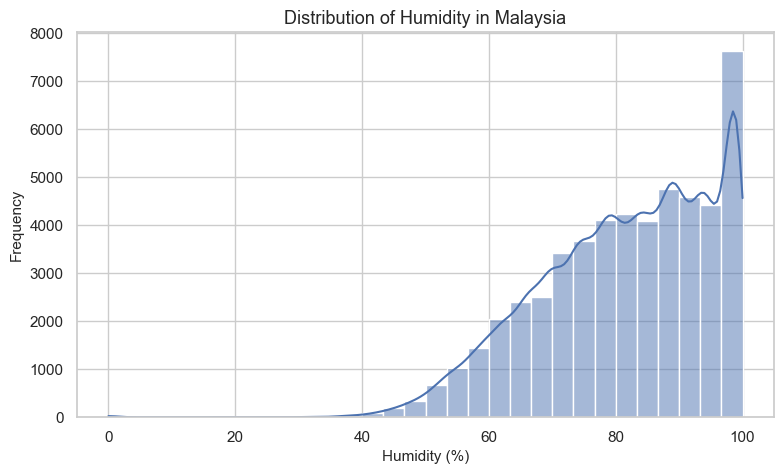

In [11]:
sns.histplot(weather['humidity'], bins=30, kde=True)
plt.title('Distribution of Humidity in Malaysia')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.show()

### Interpretation

The humidity distribution is concentrated mostly at high values. This suggests that Malaysian weather observations are often humid, which is expected in a tropical climate. However, humidity alone may not fully explain how uncomfortable the weather feels because it is affected by temperature.

## 10. Distribution of Dew Point

This histogram shows the distribution of dew point values.

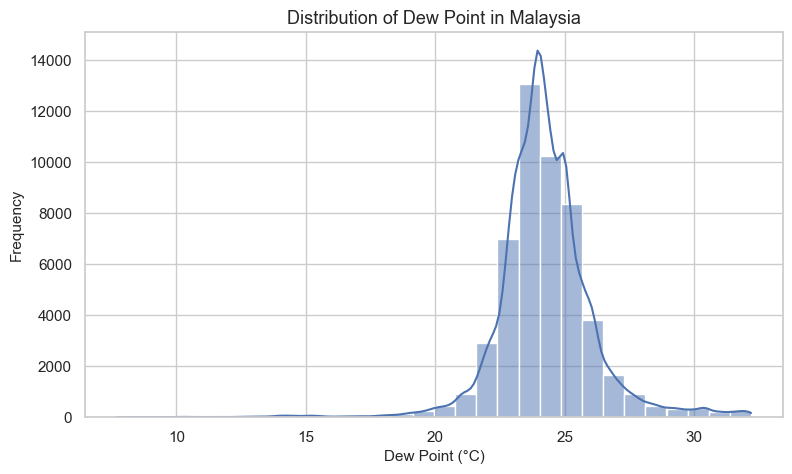

In [12]:
sns.histplot(weather['dew_point'], bins=30, kde=True)
plt.title('Distribution of Dew Point in Malaysia')
plt.xlabel('Dew Point (°C)')
plt.ylabel('Frequency')
plt.show()

### Interpretation

Most dew point values are high, with many observations around or above 24°C. This indicates that the air often contains a large amount of moisture. Since high dew point values are closely linked to muggy and sticky conditions, dew point is useful for describing oppressive weather.

## 11. Relationship Between Humidity and Dew Point

A scatter plot is used to visually examine the association between humidity and dew point.

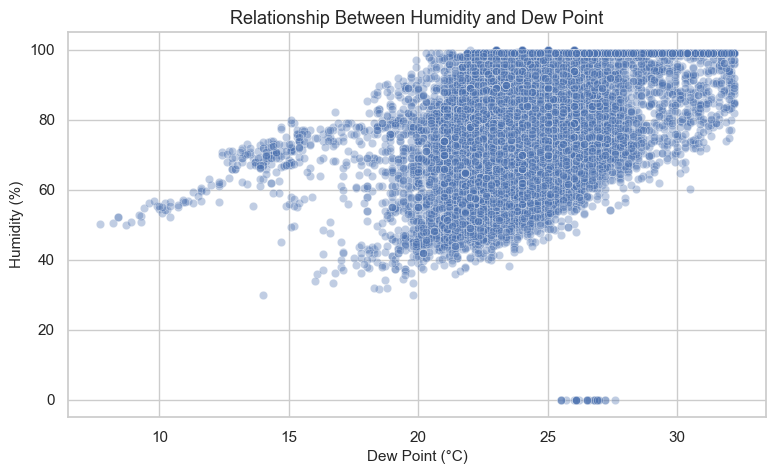

In [13]:
sns.scatterplot(data=weather, x='dew_point', y='humidity', alpha=0.35)
plt.title('Relationship Between Humidity and Dew Point')
plt.xlabel('Dew Point (°C)')
plt.ylabel('Humidity (%)')
plt.show()

### Interpretation

The scatter plot shows a general positive association between dew point and humidity. However, the points are quite spread out, meaning the relationship is not perfectly strong. This suggests that humidity and dew point are related, but they are not measuring exactly the same thing.

## 12. Correlation Analysis

Pearson correlation is used to measure the strength and direction of the relationship between humidity and dew point.

In [14]:
pearson_corr = weather['humidity'].corr(weather['dew_point'])
spearman_corr = weather['humidity'].corr(weather['dew_point'], method='spearman')

print(f'Pearson correlation between humidity and dew point: {pearson_corr:.3f}')
print(f'Spearman correlation between humidity and dew point: {spearman_corr:.3f}')

Pearson correlation between humidity and dew point: 0.315
Spearman correlation between humidity and dew point: 0.268


### Interpretation

The correlation value indicates a **positive but moderate relationship** between humidity and dew point. This means that when dew point increases, humidity tends to increase as well, but the relationship is not perfect. Therefore, humidity and dew point are associated, but they should not be treated as identical variables.

## 13. Correlation Matrix

A correlation matrix compares the relationships between temperature, humidity, and dew point.

In [15]:
corr_matrix = weather[['temperature', 'humidity', 'dew_point']].corr()
corr_matrix

,temperature,humidity,dew_point
temperature,1.000,-0.756,0.326
humidity,-0.756,1.000,0.315
dew_point,0.326,0.315,1.000


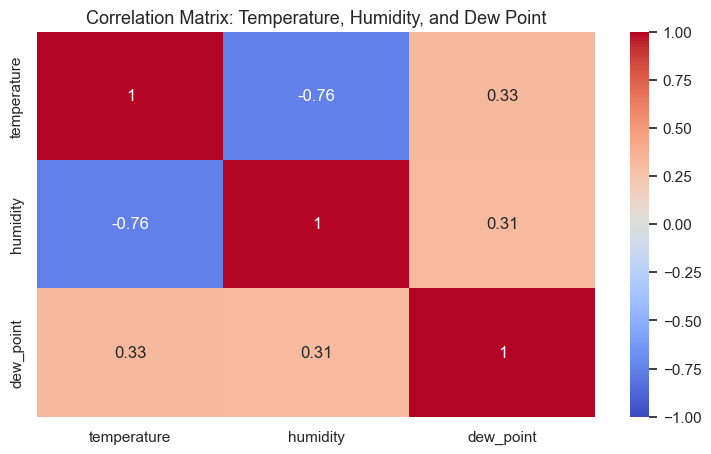

In [16]:
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Correlation Matrix: Temperature, Humidity, and Dew Point')
plt.show()

### Interpretation

Humidity has a strong negative relationship with temperature in this dataset. This happens because relative humidity depends on air temperature. When temperature increases, relative humidity can decrease even if the actual amount of moisture in the air is still high. This is one reason why humidity can be misleading when describing oppressive weather.

## 14. Oppressive Weather Threshold Using Dew Point

For this project, dew point values of **24°C or higher** are treated as an indicator of oppressive weather. This threshold is useful because high dew point means the air contains a lot of moisture.

In [17]:
weather['oppressive_dew_point'] = weather['dew_point'] >= 24

oppressive_summary = weather['oppressive_dew_point'].value_counts(normalize=True).mul(100).rename('Percentage')
oppressive_summary

oppressive_dew_point
True    57.077
False   42.923
Name: Percentage, dtype: float64

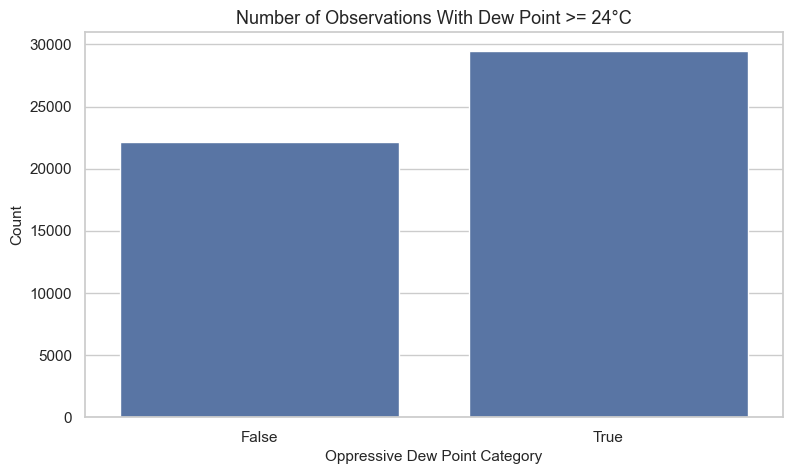

In [18]:
sns.countplot(data=weather, x='oppressive_dew_point')
plt.title('Number of Observations With Dew Point >= 24°C')
plt.xlabel('Oppressive Dew Point Category')
plt.ylabel('Count')
plt.show()

### Interpretation

A large percentage of the observations have dew point values at or above 24°C. This supports the idea that oppressive weather conditions are common in the Malaysian weather dataset.

## 15. Comparing High Humidity and High Dew Point

This section compares two possible indicators of oppressive weather:

- High humidity: humidity ≥ 80%
- High dew point: dew point ≥ 24°C

In [19]:
weather['high_humidity'] = weather['humidity'] >= 80

comparison = pd.DataFrame({
    'Condition': ['Humidity >= 80%', 'Dew Point >= 24°C', 'Both Conditions'],
    'Percentage of Observations': [
        weather['high_humidity'].mean() * 100,
        weather['oppressive_dew_point'].mean() * 100,
        (weather['high_humidity'] & weather['oppressive_dew_point']).mean() * 100
    ]
})

comparison

,Condition,Percentage of Observations
0,Humidity >= 80%,57.484
1,Dew Point >= 24°C,57.077
2,Both Conditions,36.096


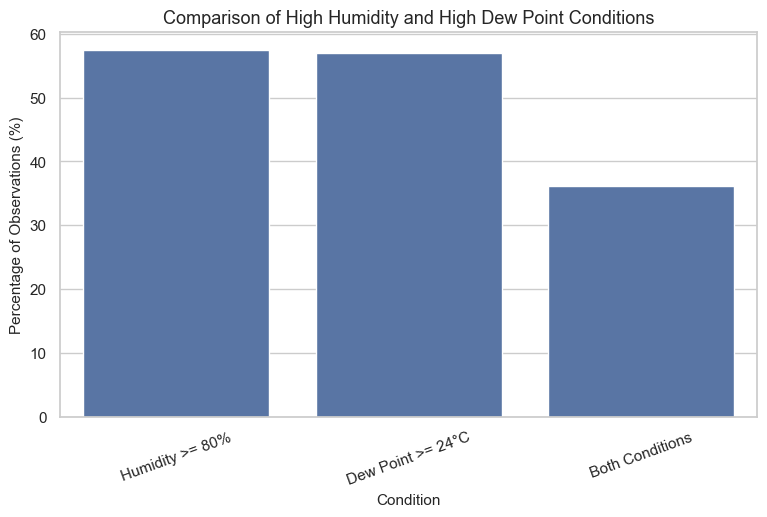

In [20]:
sns.barplot(data=comparison, x='Condition', y='Percentage of Observations')
plt.title('Comparison of High Humidity and High Dew Point Conditions')
plt.xlabel('Condition')
plt.ylabel('Percentage of Observations (%)')
plt.xticks(rotation=20)
plt.show()

### Interpretation

Both high humidity and high dew point occur frequently in the dataset. However, dew point is more directly connected to actual moisture in the air, while humidity is relative to temperature. Therefore, dew point is a more stable variable for describing whether the air feels oppressive.

## 16. Optional Extension: Heat Index Comparison

The heat index combines temperature and humidity to estimate how hot the weather feels. This section checks whether humidity or dew point is more closely related to heat index.

This part strengthens the argument about which variable better describes oppressive weather.

In [21]:
T = weather['temperature']
RH = weather['humidity']

# Heat index formula in Celsius. It is most suitable for warm conditions.
weather['heat_index'] = (
    -8.784695
    + 1.61139411 * T
    + 2.338549 * RH
    - 0.14611605 * T * RH
    - 0.012308094 * T**2
    - 0.016424828 * RH**2
    + 0.002211732 * T**2 * RH
    + 0.00072546 * T * RH**2
    - 0.000003582 * T**2 * RH**2
)

warm_weather = weather[(weather['temperature'] >= 27) & (weather['humidity'] >= 40)].copy()

heat_index_corr = warm_weather[['heat_index', 'humidity', 'dew_point', 'temperature']].corr()
heat_index_corr

,heat_index,humidity,dew_point,temperature
heat_index,1.000,-0.027,0.562,0.769
humidity,-0.027,1.000,0.651,-0.625
dew_point,0.562,0.651,1.000,0.100
temperature,0.769,-0.625,0.100,1.000


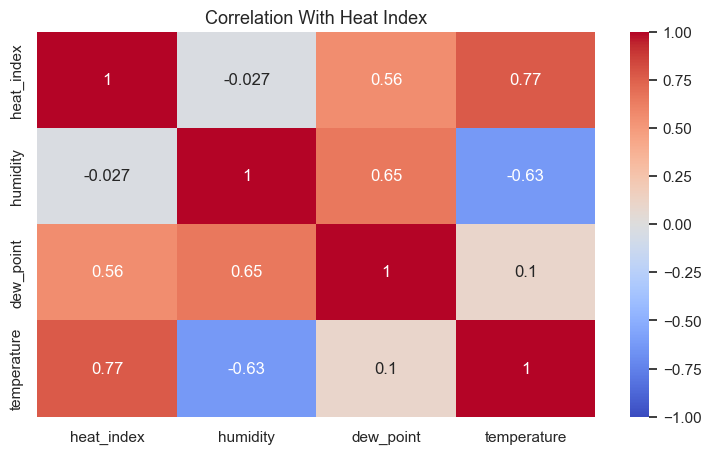

In [22]:
sns.heatmap(heat_index_corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Correlation With Heat Index')
plt.show()

### Interpretation

The heat index comparison helps evaluate which variable better represents uncomfortable weather. If dew point has a stronger positive relationship with heat index than humidity, this supports the conclusion that dew point is more useful for describing oppressive weather conditions.

## 17. Location-Based Comparison

This section compares average humidity, dew point, and temperature by state.

In [23]:
state_summary = weather.groupby('state')[['temperature', 'humidity', 'dew_point']].mean().sort_values('dew_point', ascending=False)
state_summary

,temperature,humidity,dew_point
state,,,
Pulau Pinang,28.074,81.694,24.461
Kuala Lumpur,28.061,81.207,24.181


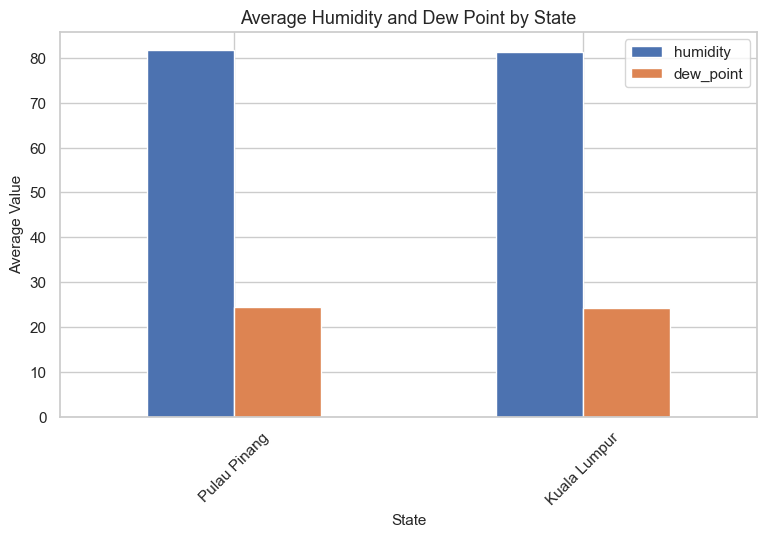

In [24]:
state_summary[['humidity', 'dew_point']].plot(kind='bar')
plt.title('Average Humidity and Dew Point by State')
plt.xlabel('State')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.show()

### Interpretation

The state-level comparison shows whether some locations have higher average dew point or humidity than others. If dew point remains consistently high across states, it further supports the idea that dew point is useful for describing oppressive weather in Malaysia.

## 18. Final Conclusion

This project investigated the association between humidity and dew point in Malaysian weather data. The results show that humidity and dew point have a **positive but moderate association**. This means that higher dew point values are generally linked with higher humidity values, but the relationship is not perfect.

Humidity is useful because it shows relative moisture in the air. However, it can be affected by temperature. For example, relative humidity may decrease when temperature rises even though the air still feels uncomfortable. This makes humidity less reliable as a single measure of oppressive weather.

Dew point is more useful for describing oppressive weather conditions because it reflects the actual amount of moisture in the air. In this dataset, many observations have dew point values around or above 24°C, which suggests frequent muggy and uncomfortable conditions. Therefore, while humidity and dew point are associated, **dew point is the better variable for describing oppressive weather in Malaysia**.

## 19. Limitations and Future Improvements

### Limitations
- The dataset may not cover all Malaysian states equally.
- The analysis mainly uses correlation, so it does not prove causation.
- Oppressive weather is partly subjective because people experience heat and humidity differently.

### Future Improvements
- Compare monsoon and non-monsoon periods.
- Analyse more cities and states separately.
- Include wind speed because wind can affect how hot or sticky the weather feels.
- Use heat index or apparent temperature as a more complete discomfort measurement.
- Build a regression model to predict oppressive weather conditions.